In [5]:
import numpy as np
import orbitengine.engine as oe
import astropy.units as u
from poliastro.bodies import Earth
from scipy.optimize import minimize
from orbitengine.body import Body
import orbitengine.transfer
from orbitengine.transfer import TransferSolver, ThrustManeuver
import time
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
from poliastro import iod
import pickle
import math
import os
from pprint import pprint
import importlib

np.set_printoptions(precision=2)

engine.py:106  Loaded from cache\TransferSolver_237f300f9e9be4cbc05680078bcead59.pkl


C:\Users\jcl5m\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ode.py:1179: UserWarning: dopri5: step size becomes too small
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,


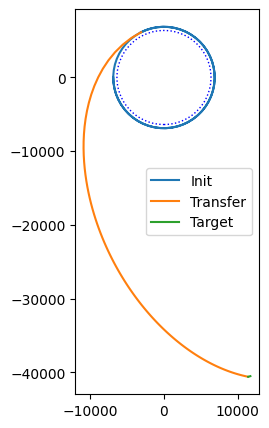

1752169162.py:28  (<Quantity 10358.25 s>, <Quantity 14944.15 s>, <orbitengine.body.Body.State object at 0x000001985E0799D0>)
1752169162.py:29:
{ 'dv1': 2.4058804222591093,
  'dv2': 1.6661729677804764,
  'k': <Quantity 398600.44 km3 / s2>,
  'state_init': <orbitengine.body.Body.State object at 0x000001985C748310>,
  'state_target': <orbitengine.body.Body.State object at 0x000001985E068850>,
  'state_transfer': <orbitengine.body.Body.State object at 0x000001985E0799D0>,
  't_delay': <Quantity 10358.25 s>,
  't_flight': <Quantity 14944.15 s>,
  'time_weight': 0.0001}


In [15]:
importlib.reload(orbitengine.transfer)
from orbitengine.transfer import TransferSolver, ThrustManeuver

# rocket on ground
r0 = np.array([oe.EARTH_RADIUS_KM.value, 0, 0])*u.km
ground_velocity = oe.EARTH_RADIUS_KM*2*np.pi/(24*3600*u.s)
v0 = np.array([0, ground_velocity.value, 0])*u.km/u.s
#m0 = 100000*u.kg # rocket + fuel
m0 = 10000*u.kg # rocket + fuel
dry_mass =  500*u.kg #rocket only
T0 = oe.TEMP_EARTH
isp = oe.SPECIFIC_IMPULSE_TYPE.Liquid
state_launch = Body.State( r0, v0, m0, T0, parent_axis_angle=oe.EARTH_AXIS_ANGLE)
cache = True
# compute a target in circular orbit
state_leo = Body.State(np.array([-oe.ALTITUDE_LEO.value, 0, 0])*u.km,
                       np.array([0, -5, 0])*u.km/u.s,   # guess
                        m0,
                        T0).circularized(oe.EARTH_K)
state_geo = Body.State(np.array([-oe.ALTITUDE_GEO.value, 0, 0])*u.km,
                       np.array([0, -5, 0])*u.km/u.s,   # guess
                        m0,
                        T0).circularized(oe.EARTH_K)

#solver = TransferSolver(state_launch, state_geo, oe.EARTH_K, time_weight=0.0001)
#solver = TransferSolver(state_launch, state_leo, oe.EARTH_K, time_weight=0.0001)
solver = TransferSolver(state_leo, state_geo, oe.EARTH_K, time_weight=0.0001)
oe.print(solver.lambert_search(resolution=10, plot=True, cache=cache))
oe.pprint(solver.__dict__, indent=2)


engine.py:106  Loaded from cache\TransferSolver_237f300f9e9be4cbc05680078bcead59.pkl
1876666311.py:8  (<Quantity 10358.25 s>, <Quantity 14944.15 s>, <orbitengine.body.Body.State object at 0x00000198618ADFD0>)
engine.py:106  Loaded from cache\ThrustManeuver_d4469b1568b644a2891971685987f669.pkl
engine.py:106  Loaded from cache\ThrustManeuver_8642d61c5802dcfd597672fb58f915c3.pkl
Timestamp: 25376.00716247801 s
Position: [ 11638.42 -40525.93      0.  ] km
Velocity: [2.96 0.85 0.  ] km / s
Mass: 6856.175622518061 kg
temperature: 450.341218874097 K

m1_dV:2.41 m2_dV:1.67  total_dV: 4.07
Initial Mass: 10000.00 kg Final Mass: 6856.18 kg
Reaction Mass Remaining: 6356.175622518061 kg
Delay, Flight: 10358.25 s, 14944.15 s
m1_init_burn: 114.76 s, m1_correction_burn: 95.68 s, alignment_err: 2.2589750227478995e-12
m2_init_burn: 83.58 s, m2_correction_burn: 73.61 s, alignment_err: 6.730538239167732e-13


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


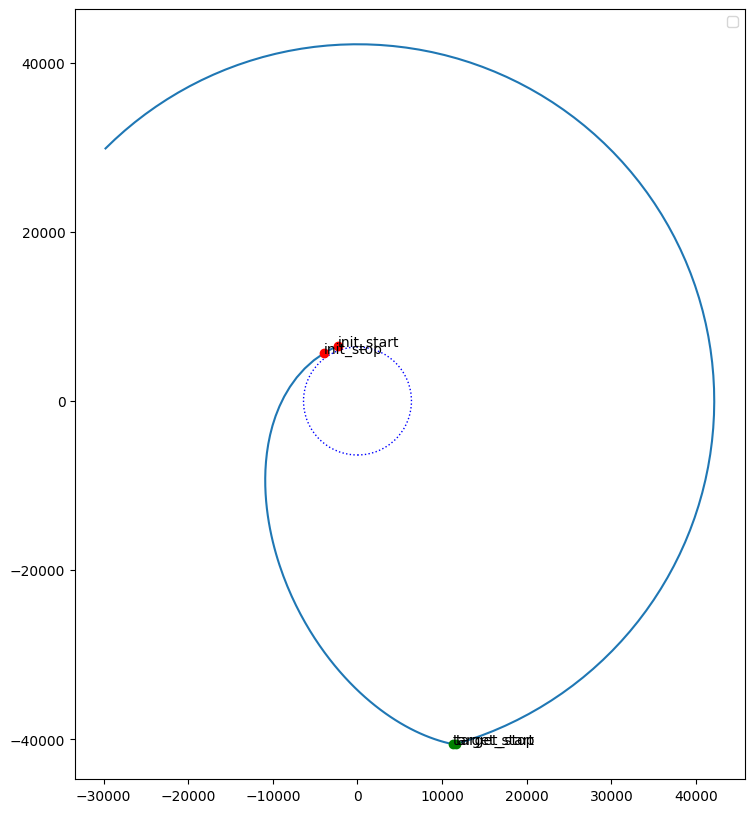

In [29]:

importlib.reload(orbitengine.transfer)
from orbitengine.transfer import TransferSolver, ThrustManeuver

# compute thrust limited maneuvers
flow_rate = 0.01*oe.FALCON9_REACTION_MASS_FLOW_RATE

solver = TransferSolver(state_leo, state_geo, oe.EARTH_K, time_weight=0.0001)
oe.print(solver.lambert_search(resolution=10, plot=False, cache=cache))

res = solver.compute_thrust_maneuvers(flow_rate, isp, dry_mass, verbose=False, cache=cache)

if res is not None:
    state, err = res
    print(state)
    print(f"m1_dV:{solver.dv1:.02f} m2_dV:{solver.dv2:.02f}  total_dV: {solver.dv1+solver.dv2:.02f}")
    print(f"Initial Mass: {m0:.02f} Final Mass: {state.mass:.02f}")
    print(f"Reaction Mass Remaining: {state.mass - dry_mass}")
    print(f"Delay, Flight: {solver.t_delay:.02f}, {solver.t_flight:.02f}")
    print(f"m1_init_burn: {solver.maneuver1.t_init_burn:.02f}, m1_correction_burn: {solver.maneuver1.t_correction_burn:.02f}, alignment_err: {solver.maneuver1.alignment_err}")
    print(f"m2_init_burn: {solver.maneuver2.t_init_burn:.02f}, m2_correction_burn: {solver.maneuver2.t_correction_burn:.02f}, alignment_err: {solver.maneuver2.alignment_err}")
    solver.plot_thrust_transfer_trajectory(show_maneuvers=True, t_postfix=50000*u.s)


In [ ]:
import cProfile

def profile():
    flow_rate = 0.01*oe.FALCON9_REACTION_MASS_FLOW_RATE
    res = solver.compute_thrust_maneuvers(flow_rate, isp, dry_mass, verbose=False)
    state, err = res
    print(state, err)
#cProfile.run('profile()', sort='cumtime')


In [15]:
import hashlib

oe.print(oe.obj_input_hash_filename(solver.maneuver1))
oe.print(oe.obj_input_hash_filename(solver.maneuver2))
oe.pprint(solver.maneuver1.input_dict())
oe.pprint(solver.maneuver2.input_dict())

# print(oe.obj_input_hash(solver.maneuver1))
# print(oe.obj_input_hash(solver.maneuver2))

obj = solver.state_transfer
oe.pprint(obj.to_dict())
# curr_precision = np.get_printoptions()['precision']
# np.set_printoptions(precision=2)
# pprint(obj.input_dict())
# #hash = hashlib.md5(str(obj.input_dict()).encode()).hexdigest()
# np.set_printoptions(precision=curr_precision)


1468709545.py:3  ThrustManeuver_088cd9116c1edec0fe49f132b900f953.pkl
1468709545.py:4  ThrustManeuver_8642d61c5802dcfd597672fb58f915c3.pkl
1468709545.py:5:
{'flow_rate': <Quantity 20. kg / s>,
 'isp': <Quantity 450. s>,
 'k': <Quantity 398600.44 km3 / s2>,
 'mass_dry': <Quantity 500. kg>,
 'state_init': {'mass': <Quantity 10000. kg>,
                'parent_axis_angle': None,
                'position': <Quantity [-6878.1,     0. ,     0. ] km>,
                'temperature': <Quantity 293.15 K>,
                'timestamp': <Quantity 0. s>,
                'velocity': <Quantity [ 0.  , -7.61,  0.  ] km / s>},
 'state_target': {'mass': <Quantity 5791.37 kg>,
                  'parent_axis_angle': None,
                  'position': <Quantity [-3108.43,  6135.59,     0.  ] km>,
                  'temperature': <Quantity 293.15 K>,
                  'timestamp': <Quantity 10358.25 s>,
                  'velocity': <Quantity [-8.93, -4.54,  0.  ] km / s>},
 't_maneuver': <Quantity 10358.25

In [ ]:
from scipy.integrate import ode
import numpy as np
import matplotlib.pyplot as plt

def logistic_model(t,y, K, r):
    dydt = t * y * (1 - y/K)
    return dydt

# Parameters for model 1
K1 = 1000
r1 = 0.5

# Parameters for model 2
K2 = 1200
r2 = 0.4

# Initial condition (same for both models)
y0 = 10

# Time points
t = np.linspace(0, 30, 100)

# Create separate LSODA integrators
solver1 = ode(logistic_model).set_integrator('dopri5')  # can use dopri5 in re-entrant mode
solver2 = ode(logistic_model).set_integrator('dopri5')

# Set initial conditions
solver1.set_initial_value(y0, t[0])
solver2.set_initial_value(y0, t[0])
solver1.set_f_params(K1, r1)
solver2.set_f_params(K2, r2)
# Solve the ODEs
solution1 = np.zeros((len(t), 1))
solution2 = np.zeros((len(t), 1))
solution1[0] = y0
solution2[0] = y0

for i in range(1, len(t)):
    solution1[i] = solver1.integrate(t[i])
    solution2[i] = solver2.integrate(t[i])

# Plot the results
plt.plot(t, solution1, label='Model 1')
plt.plot(t, solution2, label='Model 2')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Logistic Growth Comparison')
plt.legend()
plt.show()


In [ ]:
import time
import astropy.units as u
import numpy as np
import orbitengine.engine as oe
from orbitengine.body import Body

class Bucket:
    def __init__(self, a,b):
        self.a = a
        self.b = b

    def input_dict(self):
        return {
            'a': self.a.to_dict(),
            'b': self.b.to_dict()
        }
    
    def optimize(self, cache=False):
        if cache:
            if oe.obj_cache_load(self):
                return self

        time.sleep(2)
        self.c = Body.State(self.a.position + self.b.position, 
                            self.a.velocity + self.b.velocity, 
                            self.a.mass + self.b.mass, 
                            self.a.temperature + self.b.temperature)

        # Save the object to a pickle file
        if cache:
            oe.obj_cache_save(self)

        return self

cache = True
s1 = Body.State( np.array([7, 2, 3])*u.km, np.array([4, 5, 6])*u.km/u.s, 100*u.kg, 300*u.K)
s2 = Body.State( np.array([5, 6, 1])*u.km, np.array([4, 5, 6])*u.km/u.s, 100*u.kg, 300*u.K)
b = Bucket(s1,s2)
b.optimize(cache)
oe.pprint(b.input_dict())

In [ ]:
from IPython.display import display, Javascript
from notebook import notebookapp
import urllib
import json
import os
import ipykernel

def get_notebook_name():
    """Return the full path of the current notebook, or None if not found."""
    connection_file = os.path.basename(ipykernel.get_connection_file())
    kernel_id = connection_file.split('-', 1)[1].split('.')[0]

    for srv in notebookapp.list_running_servers():
        try:
            if srv['token']=='' and not srv['password']:  # No token and no password, ahem...
                req = urllib.request.urlopen(srv['url']+'api/sessions')
            else:
                req = urllib.request.urlopen(srv['url']+'api/sessions?token='+srv['token'])
            sessions = json.load(req)
            for sess in sessions:
                if sess['kernel']['id'] == kernel_id:
                    return os.path.join(srv['notebook_dir'],sess['notebook']['path'])
        except:
            pass  # There may be stale entries in the runtime directory 

print(get_notebook_name())